In [130]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
#from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer

from cloelib.summary_statistics.angular_two_point import AngularTwoPoint

from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [56]:
from cloelib.cosmology.class_cosmology import CLASSBackground, CLASSLinearPerturbations, CLASSNonLinearPerturbations

## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

In [57]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545,
                            N_mnu = 1)
linear_perturbations_CAMB = CAMBLinearPerturbations(background=background, redshifts=zs)
#linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
#nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)

Note: redshifts have been re-sorted (earliest first)


In [58]:
#class_instance = CLASSBackground(H0=70.0, Omega_cdm0=0.25, Omega_b0=0.05, w0=-1, wa=0, Omega_k0 = 0.0, 
#                            ns = 0.96, As = 2e-9, mnu = 0.06, gamma_MG = 0.545, N_mnu = 1)
#linear_perturbations_CLASS = CLASSLinearPerturbations(background=class_instance, redshifts=zs)

## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [8]:
# Execute this cell to download the data
data_downloaded = False

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

nz_example.fits downloaded successfully
mixmats_example.fits downloaded successfully
cls_example.fits downloaded successfully


In [9]:
# Read the data using euclidlib v2025.w
# Remember, only pip install euclidlib necessary!

z_nz, nz_example = el.photo.redshift_distributions('nz_example.fits')
cls_example = el.photo.angular_power_spectra('cls_example.fits')
mixmats_example = el.photo.mixing_matrices('mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

In [59]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
# Note: dndz_pos_norm and 
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

In [67]:
# Compute effective redshifts
z_effs = []
for key in dndz_pos_norm.keys():
    n = dndz_pos_norm[key]
    dz = np.gradient(z_nz)
    z_eff = np.sum(z_nz * n * dz) / np.sum(n * dz)
    z_effs.append(z_eff)

z_effs = np.array(z_effs)

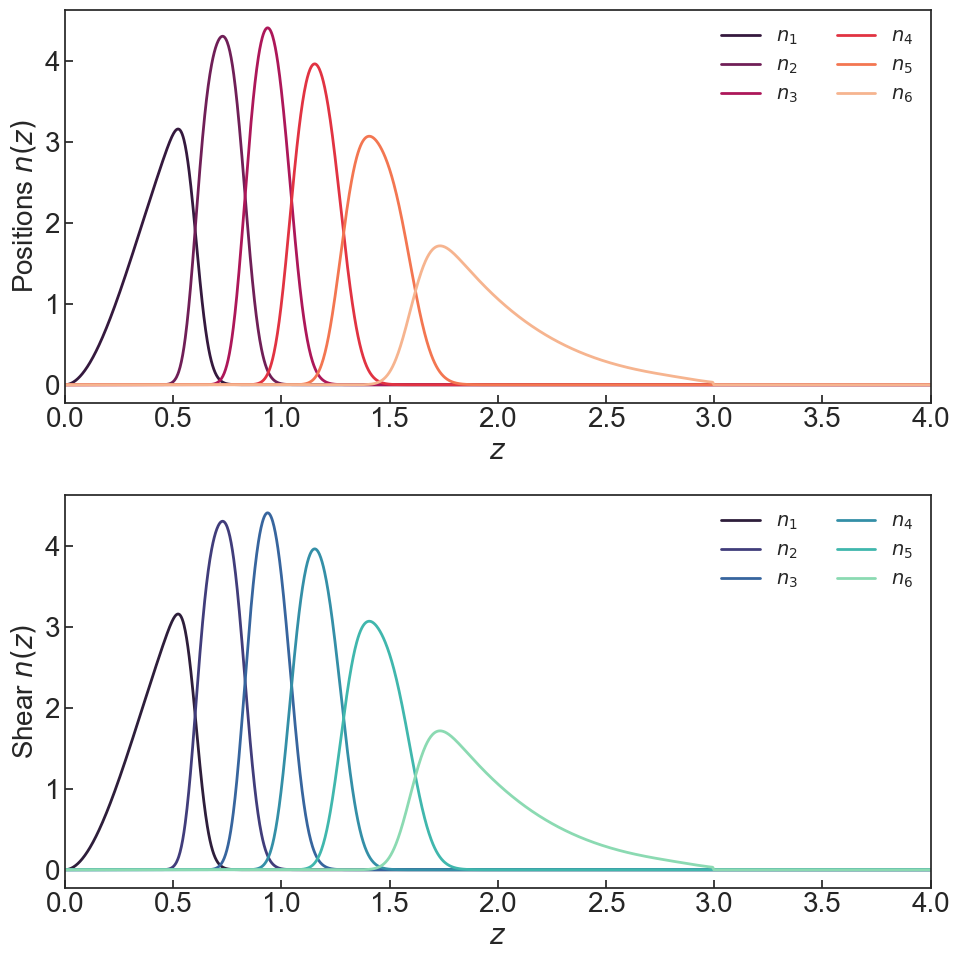

In [36]:
# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()

## Observables: shear and position tracers 

We compute tracers (window functions) for both shear and galaxy positions observations, to be later combined in the computation of the summary statistics.

In [70]:
# Select the perturbations object you want to use
perturbations = linear_perturbations_CAMB #nonlinear_perturbations_emu

# Define the tracers
tracer_pos = PositionsTracer(perturbations=perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='per_bin',
                             nuisance_params={'b1_photo_bin0': 1.0, 'b1_photo_bin1': 1.0, 
                                              'b1_photo_bin2': 1.0, 'b1_photo_bin3': 1.0,
                                              'magnification_bias_1': 1.0, 'magnification_bias_2': 1.0,
                                              'magnification_bias_3': 1.0, 'magnification_bias_4': 1.0,
                                              'magnification_bias_5': 1.0, 'magnification_bias_6': 1.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001})

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.001,
                                              'multiplicative_bias_3': 0.001, 'multiplicative_bias_4': 0.001,
                                              'multiplicative_bias_5': 0.001, 'multiplicative_bias_6': 0.001,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})

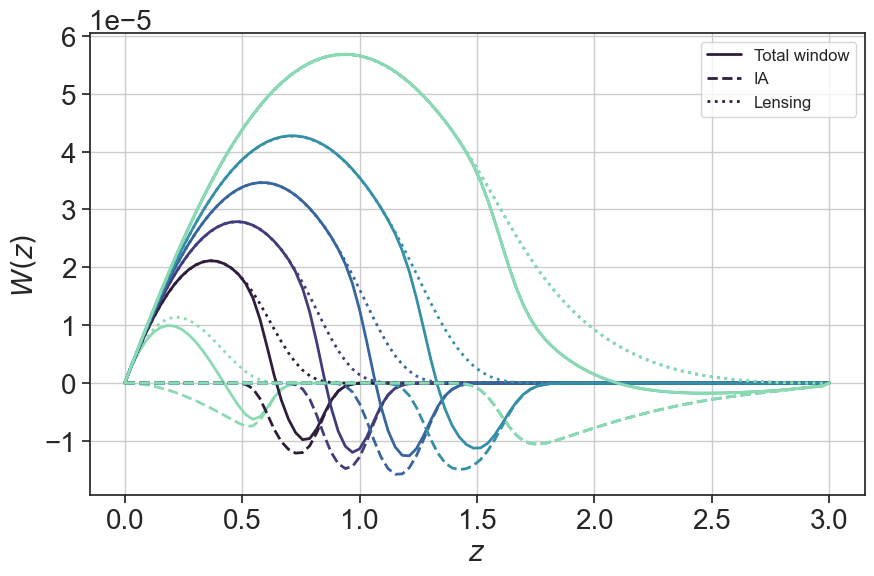

In [71]:
colors = sns.color_palette("mako", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_she.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(perturbations.z, 
             tracer_she.get_window_IA(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_she.get_window_lensing(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


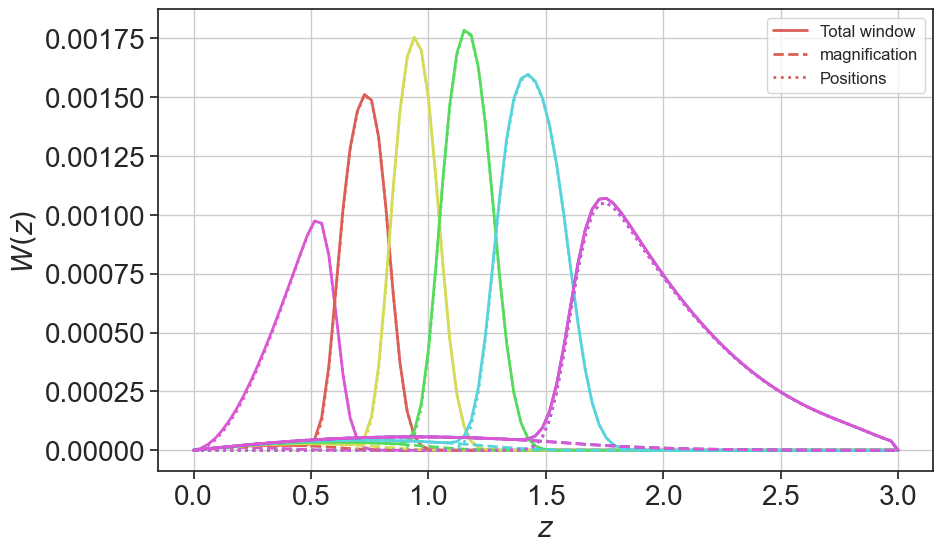

In [72]:
colors = sns.color_palette("hls", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_pos.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(perturbations.z, 
             tracer_pos.get_window_magnification(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'magnification' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_pos.get_window_positions(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Positions' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

## Weyl implementation

In [119]:
import importlib
import cloelib.observables.photo_Weyl as pw

# reload module
importlib.reload(pw)

# re-bind updated classes
PositionsTracer_Weyl_GC = pw.PositionsTracer_Weyl_GC
PositionsTracer_Weyl_GGL = pw.PositionsTracer_Weyl_GGL

In [120]:
# Calculating LCDM predictions for Jhat
from scipy.special import hyp2f1

def matter_growth(z, Omega_m0 = 0.3111):
    A = (-1+Omega_m0)/Omega_m0
    return 1/(1+z)*hyp2f1(1/3,1,11/6,A/(1+z)**3)/hyp2f1(1/3,1,11/6,A)

def sigma_8(z, Omega_m0 = 0.3111, sigma_80 = 0.811):
    return sigma_80*matter_growth(z, Omega_m0 = Omega_m0)

def Jhat_LCDM(z, Omega_m0 = 0.3111, sigma_80 = 0.811):
    
    sigma_8z = sigma_8(z, Omega_m0 = Omega_m0, sigma_80 = sigma_80)
    
    Omega_mz = Omega_m0*(1+z)**3/(Omega_m0*(1+z)**3+(1-Omega_m0))
    Jhat=Omega_mz*sigma_8z
    return Jhat

Omega_m0 = background.Omega_cdm0 + background.Omega_b0
sigma_80 = linear_perturbations_CAMB.results.get_sigma8()[-1]
Jhat_vals = Jhat_LCDM(z_effs, Omega_m0 = Omega_m0, sigma_80 = sigma_80) 

In [121]:
z_ini = 10
linear_perturbations_CAMB_Weyl = CAMBLinearPerturbations(background=background, redshifts=np.array([z_ini]))
# This is to define Weyl tracer classes with tracer.perturbations.z = np.array([z_ini])

In [122]:
growth_factor = perturbations.growth_factor(zs,1)/perturbations.growth_factor(z_ini,1)

In [123]:
growth_factors_zeff = perturbations.growth_factor(z_effs,1) # growth factors at z_eff, normalized to 1 at z=0.
sigma8_vals = sigma_80 * growth_factors_zeff #sigma8 at z_eff

In [124]:
#Create instance of class PositionsTracer_Weyl_GGL 
#bhat: bhat(z) = b(z)*sigma_8(z) corresponds to just sigma_8(z) if setting b(z)=1
#Jhat: Set to LCDM prediction
tracer_pos_Weyl_GGL = PositionsTracer_Weyl_GGL(perturbations=linear_perturbations_CAMB_Weyl, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             nuisance_params = {'bhat_bin1': sigma8_vals[0], 'bhat_bin2': sigma8_vals[1], 
                                              'bhat_bin3': sigma8_vals[2], 'bhat_bin4': sigma8_vals[3], 
                                              'bhat_bin5': sigma8_vals[4], 'bhat_bin6': sigma8_vals[5],  
                                              'magnification_bias_1': 1.0, 'magnification_bias_2': 1.0,
                                              'magnification_bias_3': 1.0, 'magnification_bias_4': 1.0,
                                              'magnification_bias_5': 1.0, 'magnification_bias_6': 1.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001},
                            Jhat_params = {'Jhat_bin1': Jhat_vals[0], 'Jhat_bin2': Jhat_vals[1], 
                                              'Jhat_bin3': Jhat_vals[2], 'Jhat_bin4': Jhat_vals[3], 
                                               'Jhat_bin5': Jhat_vals[4], 'Jhat_bin6': Jhat_vals[5]}
                                              )
#Create instance of class PositionsTracer_Weyl_GC 
#Update bhat: Should correspond to bhat(z) = b(z)*sigma_8(z) (or just sigma_8(z) if setting b(z)=1)
tracer_pos_Weyl_GC = PositionsTracer_Weyl_GC(perturbations=linear_perturbations_CAMB_Weyl, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             nuisance_params = {'bhat_bin1': sigma8_vals[0], 'bhat_bin2': sigma8_vals[1], 
                                              'bhat_bin3': sigma8_vals[2], 'bhat_bin4': sigma8_vals[3], 
                                              'bhat_bin5': sigma8_vals[4], 'bhat_bin6': sigma8_vals[5], 
                                              'magnification_bias_1': 1.0, 'magnification_bias_2': 1.0,
                                              'magnification_bias_3': 1.0, 'magnification_bias_4': 1.0,
                                              'magnification_bias_5': 1.0, 'magnification_bias_6': 1.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001})

#Shear tracer is unchanged in Weyl implementation

In [127]:
# Both are true because PositionsTracer_Weyl_GC and PositionsTracer_Weyl_GGL are child classes of PositionsTracer
print(isinstance(tracer_pos_Weyl_GC, PositionsTracer), isinstance(tracer_pos_Weyl_GGL, PositionsTracer))

True True


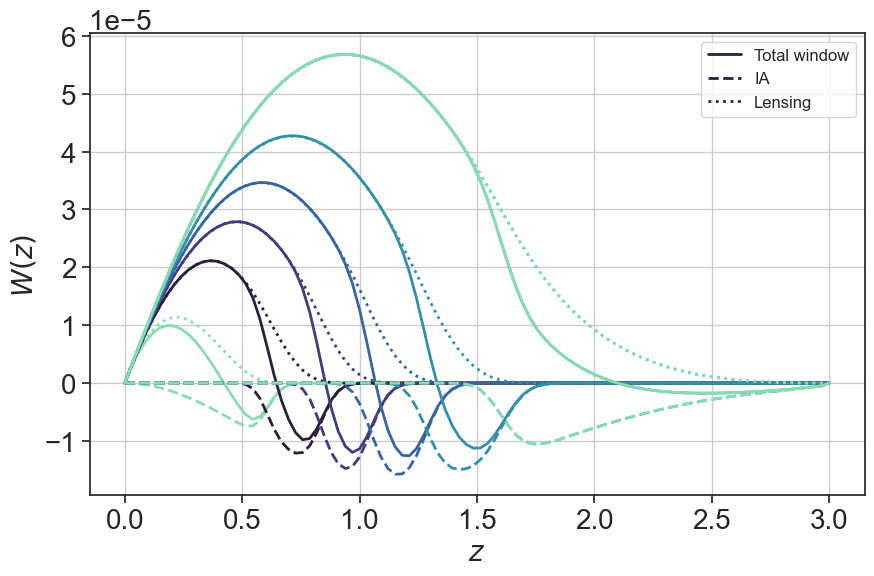

In [86]:
colors = sns.color_palette("mako", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_she_Weyl.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(perturbations.z, 
             tracer_she_Weyl.get_window_IA(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_she_Weyl.get_window_lensing(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

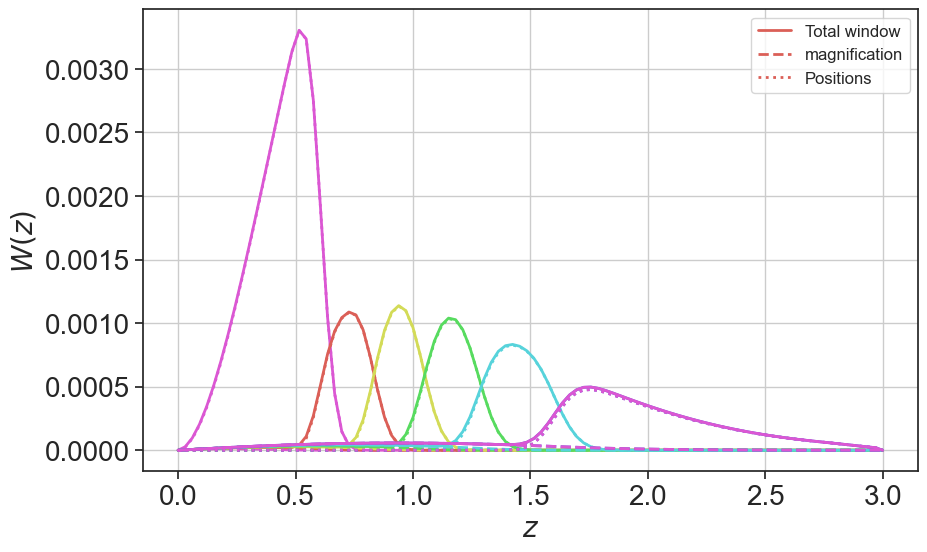

In [91]:
colors = sns.color_palette("hls", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_pos_Weyl_GGL.get_window(perturbations.z)[i, :]/growth_factor**2, 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(perturbations.z, 
             tracer_pos_Weyl_GGL.get_window_magnification(perturbations.z)[i, :]/growth_factor**2, 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'magnification' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_pos_Weyl_GGL.get_window_positions(perturbations.z)[i, :]/growth_factor**2, 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Positions' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

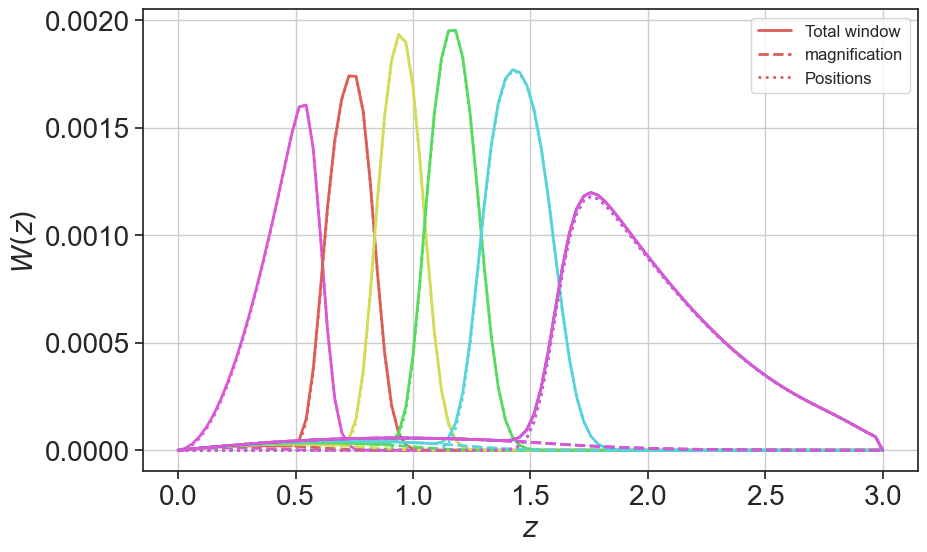

In [128]:
colors = sns.color_palette("hls", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_pos_Weyl_GC.get_window(perturbations.z)[i, :]/growth_factor, 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(perturbations.z, 
             tracer_pos_Weyl_GC.get_window_magnification(perturbations.z)[i, :]/growth_factor, 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'magnification' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_pos_Weyl_GC.get_window_positions(perturbations.z)[i, :]/growth_factor, 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Positions' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

## Two-point statistics

### Theoretical Predictions: $C_\ell$

We compute angular power spectra initialising the corresponding `cloelib` class. First, we plot the $C_\ell$ without the convolution with the mixing matrices.

In [98]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_posshe = AngularTwoPoint(tracer_pos, tracer_she)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

In [136]:
%%time
# The two stars ** are for dictionary unpacking
cells ={**twopoint_pospos.get_Cl(ells, 0, perturbations.k)
, **twopoint_shepos.get_Cl(ells, 0, perturbations.k)
, **twopoint_sheshe.get_Cl(ells, 0, perturbations.k)}

CPU times: user 42.4 s, sys: 140 ms, total: 42.6 s
Wall time: 5.87 s


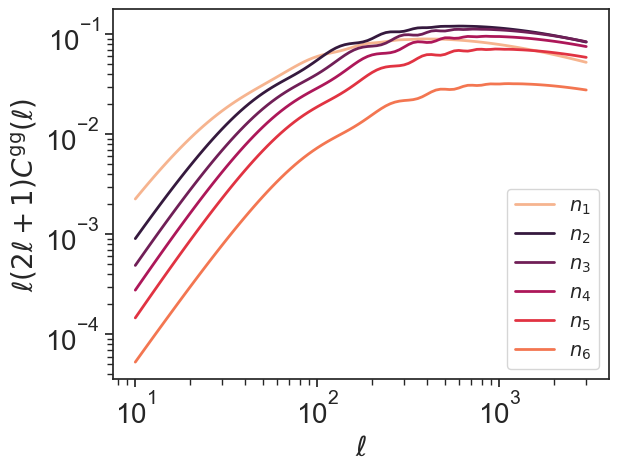

In [99]:
for i in range(0, 6):
    ells = cells['POS', 'POS', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['POS', 'POS', i+1, i+1], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

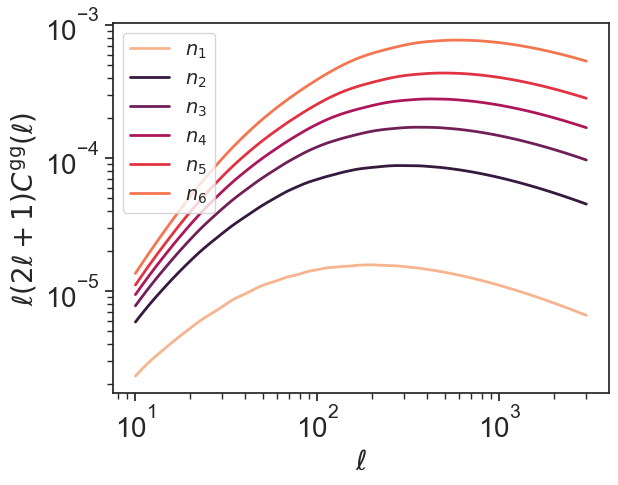

In [100]:
for i in range(0, 6):
    ells = cells['SHE', 'SHE', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['SHE', 'SHE', i+1, i+1][0, 0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

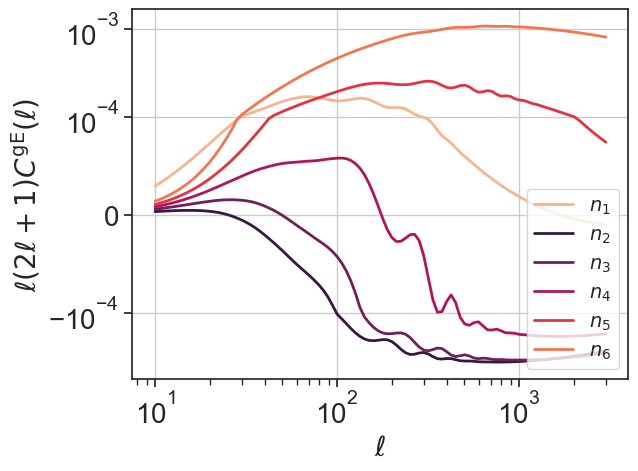

In [101]:
for i in range(0, 6):
    ells = cells['POS', 'SHE', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['POS', 'SHE', i+1, i+1][0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])

# Labels and legend
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$')
plt.legend(fontsize=14, loc=4)

# Set y-axis to symmetric log scale to handle negative values
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')
# Show the grid and the plot
plt.grid(True)
plt.show()

### Theoretical Predictions:  Weyl $C_\ell$

Now, we plot the $C_\ell$ using the Weyl implementation

In [131]:
twopoint_pospos_Weyl = AngularTwoPoint(tracer_pos_Weyl_GC, tracer_pos_Weyl_GC)
twopoint_posshe_Weyl = AngularTwoPoint(tracer_pos_Weyl_GGL, tracer_she)

In [134]:
%%time
cells_Weyl ={**twopoint_pospos_Weyl.get_Cl(ells, 0, perturbations.k)
, **twopoint_posshe_Weyl.get_Cl(ells, 0, perturbations.k)}

CPU times: user 1min 15s, sys: 348 ms, total: 1min 16s
Wall time: 11 s


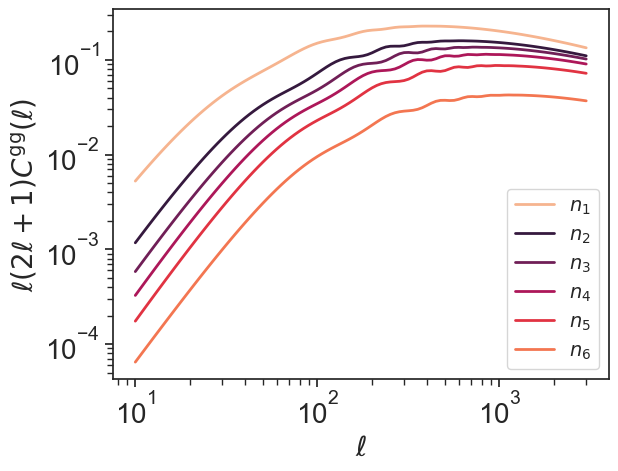

In [138]:
for i in range(0, 6):
    ells = cells_Weyl['POS', 'POS', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells_Weyl['POS', 'POS', i+1, i+1], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

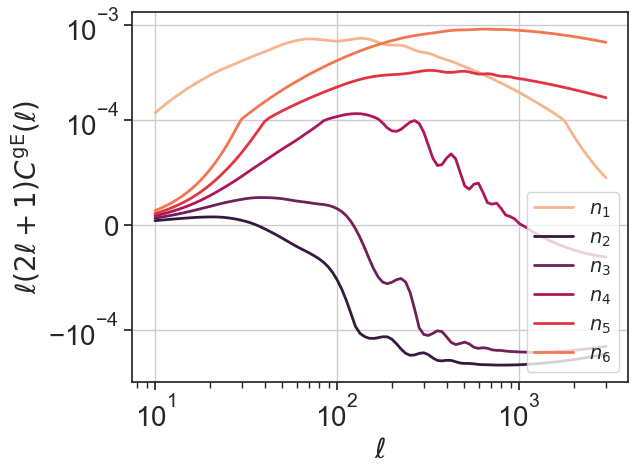

In [139]:
for i in range(0, 6):
    ells = cells['POS', 'SHE', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells_Weyl['POS', 'SHE', i+1, i+1][0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])

# Labels and legend
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$')
plt.legend(fontsize=14, loc=4)

# Set y-axis to symmetric log scale to handle negative values
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')
# Show the grid and the plot
plt.grid(True)
plt.show()